In [1]:
from langchain_openrouter import ChatOpenRouter
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.messages import SystemMessage
import os
from dotenv import load_dotenv
import requests

load_dotenv()

True

In [2]:
llm = ChatOpenRouter(
    model='openai/gpt-oss-120b:free',
)

In [3]:
# r = requests.get('http://api.weatherstack.com/',)
@tool
def weather_tool(location:str)->str:
    
    """
    use this tool for featcheing weather information 
"""
    url='http://api.weatherstack.com/current'
    params={
        'access_key':os.getenv("WEATHERSTACK_API_KEY"),
        'query': location
        }
    # d = weather_tool(location='New York')
    response = requests.get(url,params=params)
    data = response.json()
    name = data['location']['name']
    contury = data['location']['country']
    time = data['current']['observation_time']
    temp = data['current']['temperature']
    humidity = data['current']['humidity']
    weather_desc = data['current']['weather_descriptions']
    icon = data['current']['weather_icons']
    air_quality = data['current']['air_quality']

    return (f'City: {name}/Country: {contury}, Time: {time}',
            f'Temprature: {temp} Humidity: {humidity}',
            f'Weather_disctiption: {weather_desc}',
            f'Air-quality: {air_quality}\n'
            )

    if "error" in data:
        return "Error"
    
    return data


In [20]:
@tool
def cal(a:int,b:int,choice)->int:
    """USe this calculator to do basic mathematics operations"""
    if choice == '+':
        return f'Addition:{a}+{b} = {a+b}'
    elif choice == '-':
        return f'Substriction:{a}-{b} = {a-b}'
    elif choice == '*':
        return f'Multiplication:{a}x{b} = {a*b}'
    elif choice == '/':
        return f'Division:{a}/{b} = {a/b}'
    else :
        return "Error invalid input"

    return None

In [5]:
from langchain_fireworks import ChatFireworks
llm2 = ChatFireworks(
    model='accounts/fireworks/models/kimi-k2p5',
    # base_url='https://api.fireworks.ai/inference/v1',
    api_key=os.getenv('FIREWORK_API_KEY')
)

# response = llm2.invoke('who are you?')
# print(response.content)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x0000020AA8B0B4F0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x0000020AA8B5C2B0>


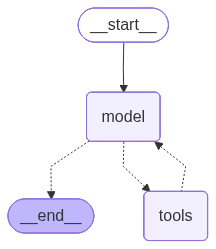

In [21]:
sys_msg = SystemMessage(
"""
You are a helpful assistant.
Whenever a user asks about weather, temperature, humidity, climate,
or forecast, ALWAYS use the weather_tool.
Never answer from your own knowledge.
""")
agent = create_agent(
    model = llm2,
    tools= [weather_tool,cal],
    system_prompt=sys_msg
)
agent

In [22]:
while True:
    user_input = input('Enter you query:')
    if user_input.lower() == 'exit':
        break
    response = agent.stream({"message":user_input})
    for chunk in response:
        print(chunk)


{'model': {'messages': [AIMessage(content="I'll check the weather in Paris for you using the weather tool.", additional_kwargs={'reasoning_content': 'The user is asking about the weather in Paris. According to the system prompt, whenever a user asks about weather, temperature, humidity, climate, or forecast, I should ALWAYS use the weather_tool and never answer from my own knowledge.\n\nThe user wants to know about Paris weather, so I should call the weather_tool with location="Paris".', 'tool_calls': [{'index': 0, 'id': 'functions.weather_tool:0', 'type': 'function', 'function': {'name': 'weather_tool', 'arguments': '{"location": "Paris"}'}}]}, response_metadata={'token_usage': {'prompt_tokens': 123, 'total_tokens': 223, 'completion_tokens': 100}, 'system_fingerprint': '', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'fireworks', 'model_name': 'accounts/fireworks/models/kimi-k2p5'}, id='lc_run--019ef21a-9100-7501-a96a-fe7ff78741b1-0', tool_calls=[{'name': 'weathe

In [23]:
while True:
    user_input = input('Enter you query:')
    response = agent.stream(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": user_input
                    }
                ]
            }
        )
    if user_input.lower() == 'exit':
        break
    for chunk in response:
            print(chunk)

{'model': {'messages': [AIMessage(content="I'll help you with both! Let me check the weather in New York and calculate 2*2 for you.", additional_kwargs={'reasoning_content': 'The user is asking two things:\n1. Weather in New York\n2. What is 2*2 (which is a calculation)\n\nAccording to the instructions, I should ALWAYS use the weather_tool when the user asks about weather. So I need to call the weather_tool for "new york".\n\nFor the calculation 2*2, I need to use the cal tool. Looking at the cal tool parameters, I need:\n- a: 2\n- b: 2\n- choice: The type parameter appears to be "any" type, which is unusual. Looking at typical calculator tools, this might represent the operation choice. Since the description says "basic mathematics operations", the choice parameter might specify which operation to perform (addition, subtraction, multiplication, division). I should probably pass something like "multiply" or "*" for multiplication.\n\nLet me make both calls since they are independent.',